# Baseline Analysis — pub-001 (8k tokens, public split)

Local analysis of `data/full_public_8k.jsonl` + `data/full_public_8k.responses.jsonl` + `data/full_public_8k_topics.json`.

Mirrors the stats in `docs/analysis/baseline-public-8k.md` and adds deeper dives.

In [25]:
import json
import re
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(REPO_ROOT, "data")):
    REPO_ROOT = os.getcwd()  # already at root
sys.path.insert(0, REPO_ROOT)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition


## 1. Load data

In [26]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

results   = load_jsonl(os.path.join(REPO_ROOT, "data", "full_public_8k.jsonl"))
responses = load_jsonl(os.path.join(REPO_ROOT, "data", "full_public_8k.responses.jsonl"))
public    = load_jsonl(os.path.join(REPO_ROOT, "data", "public.jsonl"))

with open(os.path.join(REPO_ROOT, "data", "full_public_8k_topics.json")) as f:
    topics_agg = json.load(f)

resp_map = {r["id"]: r["response"] for r in responses}
pub_map  = {p["id"]: p for p in public}

rows = []
for r in results:
    pid  = r["id"]
    p    = pub_map[pid]
    resp = resp_map.get(pid, "")
    rows.append({
        "id":               pid,
        "is_mcq":           r["is_mcq"],
        "correct":          r["correct"],
        "response":         resp,
        "resp_len":         len(resp),
        "question":         p.get("question", ""),
        "q_len":            len(p.get("question", "")),
        "gold":             r["gold"],
        "n_blanks":         len(r["gold"]) if isinstance(r["gold"], list) else 1,
        "has_boxed_letter": bool(re.search(r"\\boxed\{([A-Z])\}", resp)),
        # True when thinking block closed — model finished reasoning
        "think_finished":   "</think>" in resp,
        # Legacy char-based heuristic (kept for reference only)
        "near_cap_chars":   len(resp) >= 28_000,
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} rows  |  MCQ: {df.is_mcq.sum()}  |  Free-form: {(~df.is_mcq).sum()}")
print(f"Think finished: {df.think_finished.sum()} / {len(df)} ({100*df.think_finished.mean():.1f}%)")
print(f"Think truncated (no </think>): {(~df.think_finished).sum()} ({100*(~df.think_finished).mean():.1f}%)")


Loaded 1126 rows  |  MCQ: 375  |  Free-form: 751
Think finished: 838 / 1126 (74.4%)
Think truncated (no </think>): 288 (25.6%)


## 2. Headline metrics

In [27]:
def acc(mask):
    sub = df[mask]
    n, k = len(sub), sub.correct.sum()
    return n, k, 100 * k / n if n else 0

all_n,   all_k,   all_acc   = acc(slice(None))
mcq_n,   mcq_k,   mcq_acc   = acc(df.is_mcq)
ff_n,    ff_k,    ff_acc    = acc(~df.is_mcq)

print(f"{'Split':<15} {'N':>6} {'Correct':>8} {'Accuracy':>9}")
print("-" * 42)
print(f"{'Overall':<15} {all_n:>6} {all_k:>8} {all_acc:>8.2f}%")
print(f"{'MCQ':<15} {mcq_n:>6} {mcq_k:>8} {mcq_acc:>8.2f}%")
print(f"{'Free-form':<15} {ff_n:>6} {ff_k:>8} {ff_acc:>8.2f}%")

Split                N  Correct  Accuracy
------------------------------------------
Overall           1126      593    52.66%
MCQ                375      189    50.40%
Free-form          751      404    53.79%


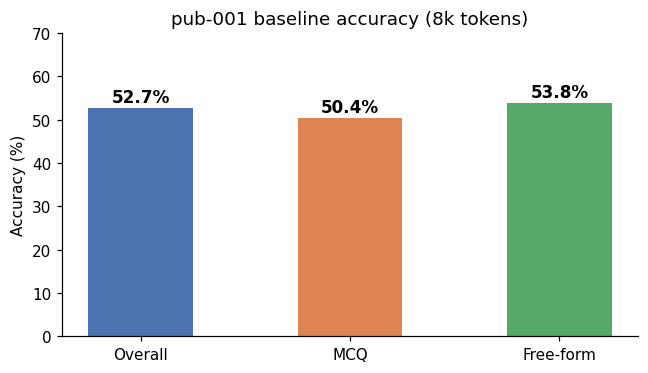

In [28]:
# Bar chart
labels = ["Overall", "MCQ", "Free-form"]
accs   = [all_acc, mcq_acc, ff_acc]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(labels, accs, color=colors, width=0.5)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 70)
ax.set_ylabel("Accuracy (%)")
ax.set_title("pub-001 baseline accuracy (8k tokens)")
plt.tight_layout()
plt.show()

## 3. MCQ deep-dive

In [29]:
mcq = df[df.is_mcq].copy()

strict_correct = mcq[mcq.has_boxed_letter & mcq.correct]
strict_n       = mcq[mcq.has_boxed_letter]
fallback_n     = mcq[~mcq.has_boxed_letter]

print("MCQ format compliance breakdown")
print(f"  Has \\boxed{{Letter}}:  {len(strict_n):>4}  ({100*len(strict_n)/len(mcq):.1f}%)")
print(f"    → correct:         {len(strict_correct):>4}  ({100*len(strict_correct)/len(strict_n):.1f}% of boxed)")
print(f"  No \\boxed{{Letter}}:   {len(fallback_n):>4}  ({100*len(fallback_n)/len(mcq):.1f}%)")
print(f"    → correct:         {fallback_n.correct.sum():>4}  ({100*fallback_n.correct.mean():.1f}% of fallback)")
print()

wrong_mcq        = mcq[~mcq.correct]
# Real truncation: model hit token limit during <think> (no </think> tag)
truncated        = (~wrong_mcq.think_finished).sum()
finished_no_box  = (wrong_mcq.think_finished & ~wrong_mcq.has_boxed_letter).sum()
wrong_box        = (wrong_mcq.think_finished &  wrong_mcq.has_boxed_letter).sum()
# Legacy char heuristic for comparison
old_near_cap     = wrong_mcq.near_cap_chars.sum()

print("Wrong MCQ failure modes  (</think>-based truncation detection)")
print(f"  Total wrong:                                {len(wrong_mcq)}")
print(f"  Truncated mid-think (no </think>):          {truncated:>4}  ({100*truncated/len(wrong_mcq):.1f}%)")
print(f"  Think finished, no \\boxed{{Letter}}:        {finished_no_box:>4}  ({100*finished_no_box/len(wrong_mcq):.1f}%)")
print(f"  Think finished, wrong \\boxed{{Letter}}:     {wrong_box:>4}  ({100*wrong_box/len(wrong_mcq):.1f}%)")
print()
print(f"  [Old char-heuristic near-cap (≥28k):        {old_near_cap:>4}  ({100*old_near_cap/len(wrong_mcq):.1f}%)]  ← was badly wrong")


MCQ format compliance breakdown
  Has \boxed{Letter}:   205  (54.7%)
    → correct:          181  (88.3% of boxed)
  No \boxed{Letter}:    170  (45.3%)
    → correct:            8  (4.7% of fallback)

Wrong MCQ failure modes  (</think>-based truncation detection)
  Total wrong:                                186
  Truncated mid-think (no </think>):           157  (84.4%)
  Think finished, no \boxed{Letter}:           5  (2.7%)
  Think finished, wrong \boxed{Letter}:       24  (12.9%)

  [Old char-heuristic near-cap (≥28k):           6  (3.2%)]  ← was badly wrong


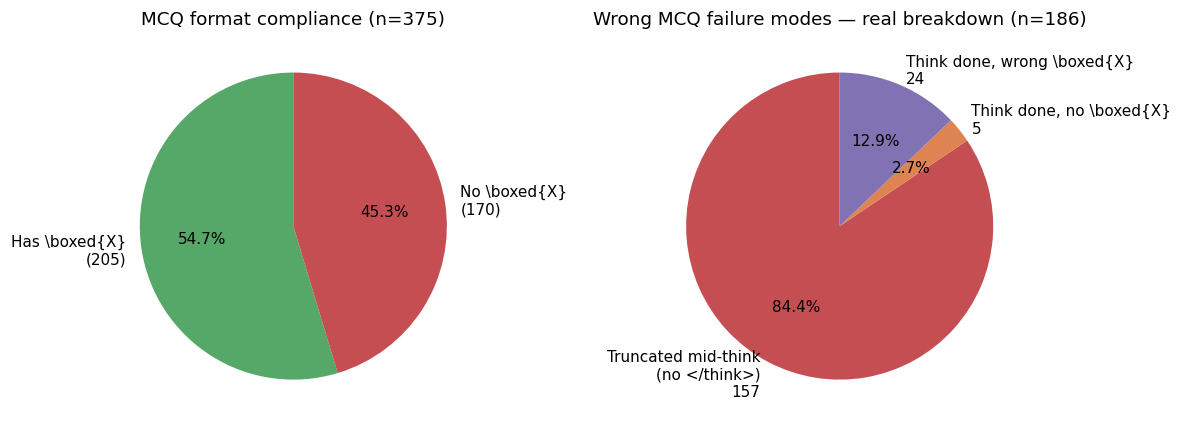


Key insight: the dominant failure is token truncation during reasoning,
not format non-compliance. The 28k-char heuristic missed this because
math LaTeX tokenises at ~1.5-2 chars/token, not ~4 chars/token.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: format compliance (unchanged)
axes[0].pie(
    [len(strict_n), len(fallback_n)],
    labels=[f"Has \\boxed{{X}}\n({len(strict_n)})", f"No \\boxed{{X}}\n({len(fallback_n)})"],
    colors=["#55A868", "#C44E52"],
    autopct="%1.1f%%", startangle=90
)
axes[0].set_title("MCQ format compliance (n=375)")

# Right: wrong MCQ — three real failure modes
labels_3 = [
    f"Truncated mid-think\n(no </think>)\n{truncated}",
    f"Think done, no \\boxed{{X}}\n{finished_no_box}",
    f"Think done, wrong \\boxed{{X}}\n{wrong_box}",
]
axes[1].pie(
    [truncated, finished_no_box, wrong_box],
    labels=labels_3,
    colors=["#C44E52", "#DD8452", "#8172B3"],
    autopct="%1.1f%%", startangle=90
)
axes[1].set_title(f"Wrong MCQ failure modes — real breakdown (n={len(wrong_mcq)})")

plt.tight_layout()
plt.show()

print()
print("Key insight: the dominant failure is token truncation during reasoning,")
print("not format non-compliance. The 28k-char heuristic missed this because")
print("math LaTeX tokenises at ~1.5-2 chars/token, not ~4 chars/token.")


## 3b. MCQ no-boxed samples

Examine what the model actually outputs when it **fails to produce `\\boxed{X}`** — both wrong and (rare) correct cases.

In [31]:
import textwrap

def show_mcq_sample(row, label=""):
    q = pub_map[row.id]["question"]
    opts = pub_map[row.id].get("options", [])
    gold = row.gold
    resp_tail = row.response[-2000:]  # last 2k chars — where answer should appear
    sep = "=" * 72
    print(sep)
    print(f"ID={row.id}  correct={row.correct}  resp_len={row.resp_len:,}  {label}")
    print(f"QUESTION: {textwrap.shorten(q, 200)}")
    if opts:
        for i, o in enumerate(opts):
            letter = chr(ord('A') + i)
            marker = " ← GOLD" if letter == gold else ""
            print(f"  {letter}) {textwrap.shorten(o, 80)}{marker}")
    print(f"GOLD: {gold}")
    print()
    print("--- RESPONSE TAIL (last 2000 chars) ---")
    print(resp_tail)
    print()


In [32]:
# Wrong MCQ with no boxed letter — 10 random samples
import random
random.seed(42)

no_box_wrong = df[df.is_mcq & ~df.has_boxed_letter & ~df.correct]
print(f"Pool: {len(no_box_wrong)} wrong MCQ without \\boxed{{X}}")
print()

sample_ids = random.sample(list(no_box_wrong.index), min(10, len(no_box_wrong)))
for idx in sample_ids:
    show_mcq_sample(df.loc[idx], label="[WRONG, no boxed]")


Pool: 162 wrong MCQ without \boxed{X}

ID=153  correct=False  resp_len=23,467  [WRONG, no boxed]
QUESTION: In $\triangle{ABC}$ , let $D$ and $E$ be points on sides $AC$ and $BC$ , respectively, so that $DE$ is parallel to $AB$ . Let $P$ be the intersection of $AE$ and $BD$ , and assume that the area [...]
  A) 384
  B) 376
  C) 369
  D) 385
  E) 390
  F) 375
  G) 391
  H) 396 ← GOLD
  I) 361
  J) 380
GOLD: H

--- RESPONSE TAIL (last 2000 chars) ---
= n, mass at D = m + n, so BP/PD = (m + n)/n.

Wait, let's set AD/DC = k, so mass at A = k, mass at C = 1, so mass at D = k + 1.

Then BE/EC = k (since DE || AB), so mass at B = 1, mass at C = k, so mass at E = 1 + k.

Then, on line AE: mass at A = k, mass at E = 1 + k, so AP/PE = (1 + k)/k.

On line BD: mass at B = 1, mass at D = k + 1, so BP/PD = (k + 1)/1.

Now, let's compute areas.

Let [PDE] = 25, [ABP] = 36.

Let’s denote [PDE] = 25, [APD] = a, [BPD] = b, so a + b = 36.

Since AP/PE = (1 + k)/k, the area of APD / area of EDP = (AP / PE

In [33]:
# Correct MCQ with no boxed letter — all of them (only ~8 exist)
no_box_correct = df[df.is_mcq & ~df.has_boxed_letter & df.correct]
print(f"Correct MCQ without \\boxed{{X}}: {len(no_box_correct)} items")
print("(These survived on the fallback letter heuristic)")
print()

for idx in no_box_correct.index:
    show_mcq_sample(df.loc[idx], label="[CORRECT via fallback]")


Correct MCQ without \boxed{X}: 8 items
(These survived on the fallback letter heuristic)

ID=246  correct=True  resp_len=23,622  [CORRECT via fallback]
QUESTION: We now define an algorithm: The definition of a(n) is the number of inequivalent Gaussian primes (complex integers of form a+bi, where a and b are integers) whose norm is n. Given the input [...]
  A) [0, 0, 0, 0, 0, 0, 2, 0, 0, 0] ← GOLD
  B) [1, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  C) [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  D) [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
  E) [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  F) [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  G) [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  H) [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
  I) [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  J) [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
GOLD: A

--- RESPONSE TAIL (last 2000 chars) ---
 since 5 splits into (2+i)(2-i), each has norm 5. So the Gaussian primes with norm 5 are the factors. But norm 25 would be for primes like 5 (in Z), but wait, no.

Wait, I think the confusion arises here. Let's clarify:

In Ga

In [34]:
# Pattern analysis: what does the model write at the end instead of \boxed{X}?
import collections

ending_patterns = []
for idx in no_box_wrong.index:
    tail = df.loc[idx, "response"][-500:]
    ending_patterns.append(tail)

# Look for common closing phrases
phrases = [
    r"the answer is",
    r"answer is",
    r"\*\*[A-Z]\*\*",     # **A**
    r"option [A-Z]",
    r"choice [A-Z]",
    r"correct answer",
    r"therefore",
    r"thus",
    r"\\textbf\{[A-Z]\}", # \textbf{A}
    r"so the answer",
]

print("Phrase frequency in last 500 chars of no-boxed wrong MCQ responses:")
print()
for phrase in phrases:
    hits = sum(1 for t in ending_patterns if re.search(phrase, t, re.IGNORECASE))
    print(f"  {phrase:<35} {hits:>4} / {len(ending_patterns)} ({100*hits/len(ending_patterns):.0f}%)")


Phrase frequency in last 500 chars of no-boxed wrong MCQ responses:

  the answer is                          7 / 162 (4%)
  answer is                              9 / 162 (6%)
  \*\*[A-Z]\*\*                          0 / 162 (0%)
  option [A-Z]                          44 / 162 (27%)
  choice [A-Z]                           2 / 162 (1%)
  correct answer                         3 / 162 (2%)
  therefore                             16 / 162 (10%)
  thus                                   3 / 162 (2%)
  \\textbf\{[A-Z]\}                      0 / 162 (0%)
  so the answer                          1 / 162 (1%)


## 4. Free-form deep-dive: single vs multi-blank

In [35]:
ff = df[~df.is_mcq].copy()

single = ff[ff.n_blanks == 1]
multi  = ff[ff.n_blanks > 1]

print(f"Single-blank:  {len(single):>4}  acc={100*single.correct.mean():.1f}%")
print(f"Multi-blank:   {len(multi):>4}  acc={100*multi.correct.mean():.1f}%")
print()
print("Multi-blank distribution:")
print(ff.n_blanks.value_counts().sort_index())

Single-blank:   337  acc=61.1%
Multi-blank:    414  acc=47.8%

Multi-blank distribution:
n_blanks
1     337
2     171
3      90
4      59
5      31
6      20
7      12
8      12
9       4
10      5
11      1
12      2
13      1
14      2
15      2
24      1
42      1
Name: count, dtype: int64


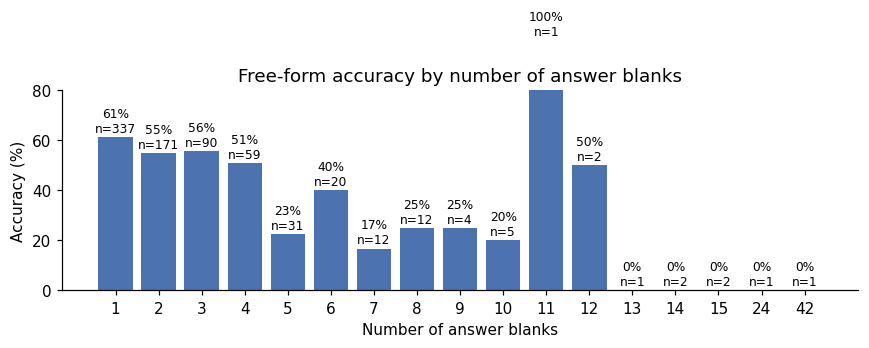

In [36]:
# Accuracy by number of blanks
blank_acc = ff.groupby("n_blanks").agg(n=("correct", "count"), acc=("correct", "mean")).reset_index()
blank_acc["acc"] *= 100

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(blank_acc.n_blanks.astype(str), blank_acc.acc, color="#4C72B0")
for bar, row in zip(bars, blank_acc.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, row.acc + 0.8,
            f"{row.acc:.0f}%\nn={row.n}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Number of answer blanks")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Free-form accuracy by number of answer blanks")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

## 5. Response length analysis

In [37]:
for label, mask in [("MCQ", df.is_mcq), ("Free-form", ~df.is_mcq)]:
    sub = df[mask]
    corr_len  = sub[sub.correct].resp_len.mean()
    wrong_len = sub[~sub.correct].resp_len.mean()
    print(f"{label}  correct mean: {corr_len:,.0f} chars   wrong mean: {wrong_len:,.0f} chars")

MCQ  correct mean: 12,490 chars   wrong mean: 20,089 chars
Free-form  correct mean: 6,204 chars   wrong mean: 14,094 chars


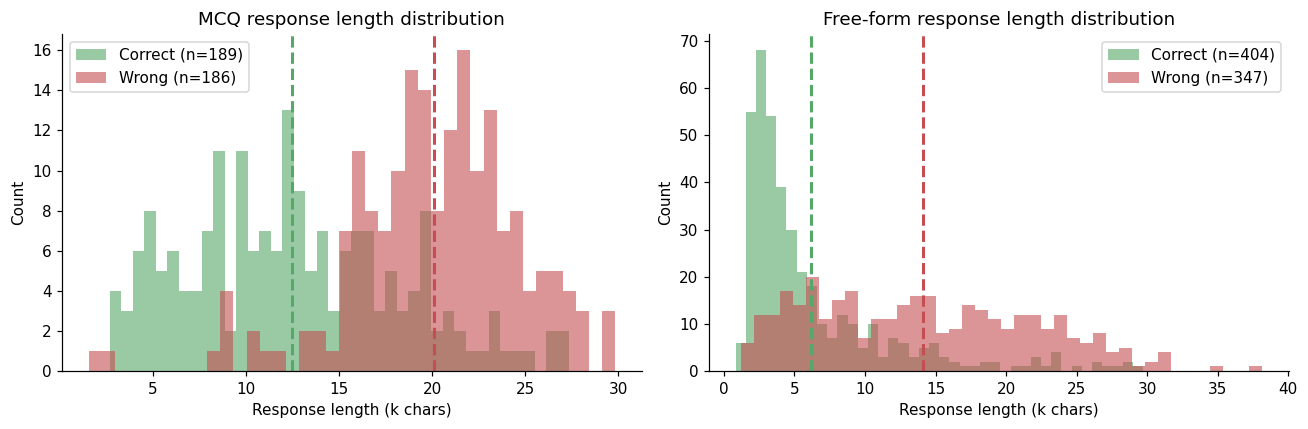

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (label, mask) in zip(axes, [("MCQ", df.is_mcq), ("Free-form", ~df.is_mcq)]):
    sub = df[mask]
    corr  = sub[sub.correct].resp_len / 1000
    wrong = sub[~sub.correct].resp_len / 1000
    ax.hist(corr,  bins=40, alpha=0.6, color="#55A868", label=f"Correct (n={len(corr)})")
    ax.hist(wrong, bins=40, alpha=0.6, color="#C44E52", label=f"Wrong (n={len(wrong)})")
    ax.axvline(corr.mean(),  color="#55A868", lw=2, linestyle="--")
    ax.axvline(wrong.mean(), color="#C44E52", lw=2, linestyle="--")
    ax.set_xlabel("Response length (k chars)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} response length distribution")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Question length vs accuracy

In [39]:
corr_q  = df[df.correct].q_len.mean()
wrong_q = df[~df.correct].q_len.mean()
print(f"Correct question mean length:   {corr_q:.0f} chars")
print(f"Incorrect question mean length: {wrong_q:.0f} chars")

# Bucket by quartile
df["q_quartile"] = pd.qcut(df.q_len, 4, labels=["Q1 (short)", "Q2", "Q3", "Q4 (long)"])
q_acc = df.groupby("q_quartile", observed=True).agg(n=("correct", "count"), acc=("correct", "mean")).reset_index()
q_acc["acc"] *= 100
print()
print(q_acc.to_string(index=False))

Correct question mean length:   287 chars
Incorrect question mean length: 470 chars

q_quartile   n       acc
Q1 (short) 283 72.084806
        Q2 281 55.871886
        Q3 281 47.686833
 Q4 (long) 281 34.875445


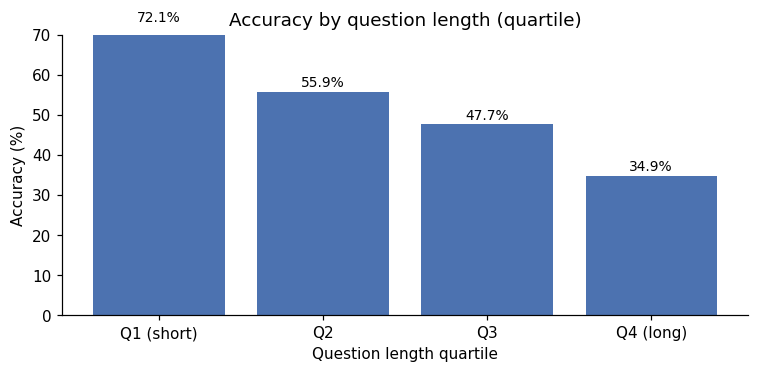

In [40]:
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(q_acc.q_quartile.astype(str), q_acc.acc, color="#4C72B0")
for bar, row in zip(bars, q_acc.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, row.acc + 0.5,
            f"{row.acc:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Question length quartile")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by question length (quartile)")
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()

## 7. Topic-level breakdown

In [41]:
topic_rows = []
for topic, v in topics_agg.items():
    topic_rows.append({
        "topic":        topic,
        "n":            v["n"],
        "correct":      v["correct"],
        "accuracy":     v["accuracy"],
        "mcq_n":        v["mcq_n"],
        "mcq_correct":  v["mcq_correct"],
        "mcq_accuracy": v["mcq_accuracy"],
    })

tdf = pd.DataFrame(topic_rows).sort_values("accuracy")

print(f"{'Topic':<30} {'N':>6} {'Acc':>7} {'MCQ N':>6} {'MCQ Acc':>9}")
print("-" * 65)
for _, r in tdf.iterrows():
    print(f"{r.topic:<30} {r.n:>6} {r.accuracy:>6.1f}% {r.mcq_n:>6} {r.mcq_accuracy:>8.1f}%")

Topic                               N     Acc  MCQ N   MCQ Acc
-----------------------------------------------------------------
number theory                      23   30.4%     21     28.6%
sequences/recurrences              75   34.7%     61     34.4%
geometry                          115   35.6%     39     28.2%
limits                             14   35.7%      7     71.4%
probability/stats                  82   50.0%     29     69.0%
linear algebra                     23   52.2%     19     63.2%
other                             581   56.1%    102     42.2%
derivatives                        12   58.3%     12     58.3%
polynomials/algebra               146   59.6%     30     76.7%
integration                        55   74.5%     55     74.5%


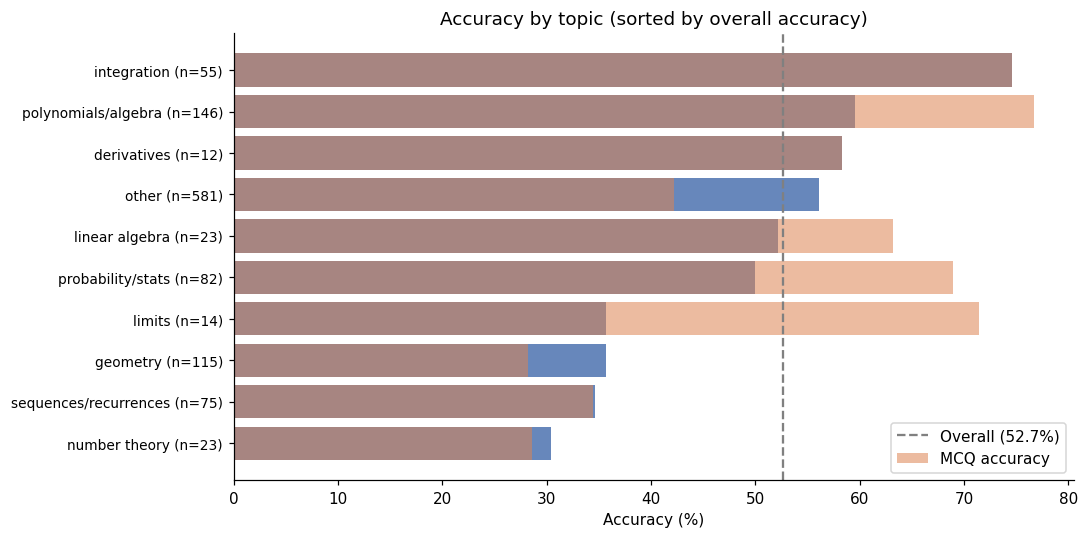

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(tdf))
bars = ax.barh(list(y), tdf.accuracy, color="#4C72B0", alpha=0.85)
ax.barh(list(y), tdf.mcq_accuracy, color="#DD8452", alpha=0.55, label="MCQ accuracy")

ax.set_yticks(list(y))
ax.set_yticklabels([f"{t} (n={n})" for t, n in zip(tdf.topic, tdf.n)], fontsize=9)
ax.axvline(all_acc, color="gray", linestyle="--", lw=1.5, label=f"Overall ({all_acc:.1f}%)")
ax.set_xlabel("Accuracy (%)")
ax.set_title("Accuracy by topic (sorted by overall accuracy)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Opportunity sizing: MCQ format fix

In [43]:
# If all MCQ responses had \boxed{X} and the boxed-rate accuracy held,
# how many extra correct would we get?
boxed_rate = len(strict_correct) / len(strict_n)  # accuracy when boxed present
fallback_correct_now = fallback_n.correct.sum()
fallback_correct_if_fixed = len(fallback_n) * boxed_rate
extra = fallback_correct_if_fixed - fallback_correct_now

new_mcq_correct  = mcq_k + extra
new_total        = all_k + extra
new_overall_acc  = 100 * new_total / all_n
new_mcq_acc      = 100 * new_mcq_correct / mcq_n

print("Optimistic ceiling if all MCQ had \\boxed{X} (same boxed accuracy):")
print(f"  boxed accuracy rate:     {100*boxed_rate:.1f}%")
print(f"  extra correct:           +{extra:.0f}")
print(f"  MCQ accuracy:            {mcq_acc:.1f}% → {new_mcq_acc:.1f}% (+{new_mcq_acc-mcq_acc:.1f} pp)")
print(f"  Overall accuracy:        {all_acc:.2f}% → {new_overall_acc:.2f}% (+{new_overall_acc-all_acc:.2f} pp)")

Optimistic ceiling if all MCQ had \boxed{X} (same boxed accuracy):
  boxed accuracy rate:     88.3%
  extra correct:           +142
  MCQ accuracy:            50.4% → 88.3% (+37.9 pp)
  Overall accuracy:        52.66% → 65.28% (+12.62 pp)


## 9. Opportunity sizing: weak topic uplift

In [44]:
# Weakest 3 topics: what if we brought them to overall average?
weak_topics = tdf.head(3)
target_acc  = all_acc / 100

total_extra = 0
print(f"Target accuracy: {all_acc:.1f}%")
print()
for _, r in weak_topics.iterrows():
    curr = r.accuracy / 100
    extra_k = (target_acc - curr) * r.n
    total_extra += extra_k
    print(f"  {r.topic:<35} {r.accuracy:>5.1f}% → {all_acc:.1f}%  +{extra_k:.0f} correct")

new_overall = 100 * (all_k + total_extra) / all_n
print(f"\n  Combined uplift: +{total_extra:.0f} correct → overall {new_overall:.2f}% (+{new_overall-all_acc:.2f} pp)")

Target accuracy: 52.7%

  number theory                        30.4% → 52.7%  +5 correct
  sequences/recurrences                34.7% → 52.7%  +13 correct
  geometry                             35.6% → 52.7%  +20 correct

  Combined uplift: +38 correct → overall 56.05% (+3.39 pp)


## 10. Response truncation check

In [45]:
# Correct truncation detection: </think> absence means model hit token cap mid-think.
# Math LaTeX tokenises at ~1.5-2 chars/token (vs ~4 for plain text), so the
# old 28k-char threshold (~8k tokens at 3.5 c/t) severely undercounted truncations.

trunc_all = (~df.think_finished).sum()
trunc_mcq = (~mcq.think_finished).sum()
trunc_ff  = (~ff.think_finished).sum()

print("Responses truncated mid-think (no </think> tag):")
print(f"  Overall:   {trunc_all} / {len(df)} ({100*trunc_all/len(df):.1f}%)")
print(f"  MCQ:       {trunc_mcq} / {len(mcq)} ({100*trunc_mcq/len(mcq):.1f}%)")
print(f"  Free-form: {trunc_ff} / {len(ff)} ({100*trunc_ff/len(ff):.1f}%)")
print()

# Char/token ratio estimate for truncated responses (should be near 8192 tokens)
trunc_df = df[~df.think_finished]
mean_chars = trunc_df.resp_len.mean()
est_ctok   = mean_chars / 8192
print(f"Mean chars of truncated responses: {mean_chars:,.0f}")
print(f"Implied chars/token at 8k cap:      {est_ctok:.2f}  (plain text ≈ 4, math LaTeX ≈ 1.5-2)")
print()

# Accuracy impact: are truncated responses less likely to be correct?
print("Accuracy by truncation status:")
for label, mask in [("Think finished", df.think_finished), ("Think truncated", ~df.think_finished)]:
    sub = df[mask]
    print(f"  {label:<20} n={len(sub):>4}  acc={100*sub.correct.mean():.1f}%")
print()

# Old heuristic vs real count
old_trunc = df.near_cap_chars.sum()
print(f"Old char-heuristic (≥28k): {old_trunc} truncated  ← missed {trunc_all - old_trunc} real truncations")


Responses truncated mid-think (no </think> tag):
  Overall:   288 / 1126 (25.6%)
  MCQ:       165 / 375 (44.0%)
  Free-form: 123 / 751 (16.4%)

Mean chars of truncated responses: 20,877
Implied chars/token at 8k cap:      2.55  (plain text ≈ 4, math LaTeX ≈ 1.5-2)

Accuracy by truncation status:
  Think finished       n= 838  acc=69.5%
  Think truncated      n= 288  acc=3.8%

Old char-heuristic (≥28k): 23 truncated  ← missed 265 real truncations


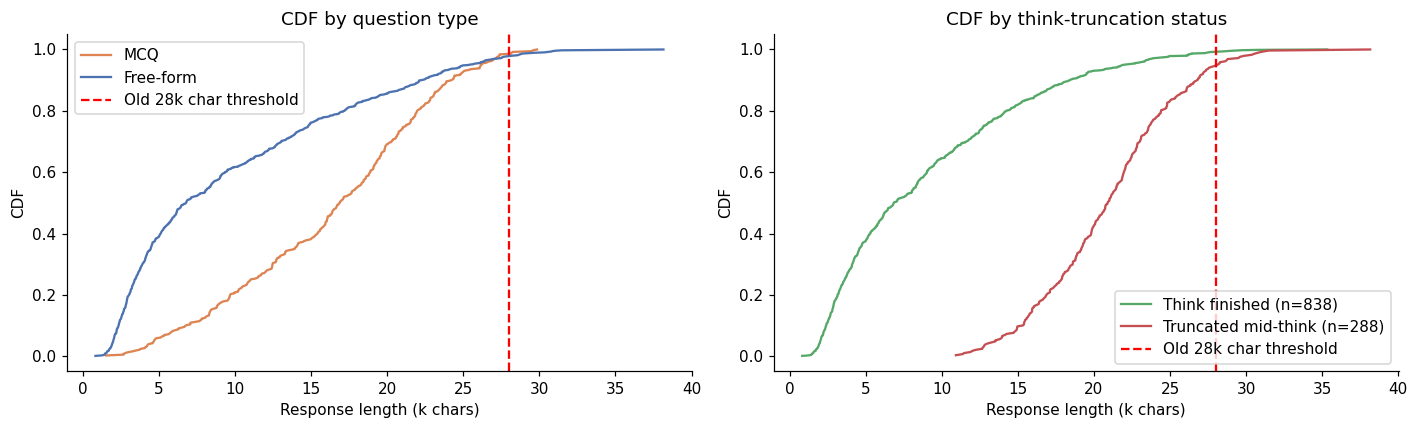

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: CDF by question type (unchanged)
ax = axes[0]
for label, sub, color in [("MCQ", mcq, "#DD8452"), ("Free-form", ff, "#4C72B0")]:
    s = np.sort(sub.resp_len / 1000)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, color=color)
ax.axvline(28, color="red", linestyle="--", lw=1.5, label="Old 28k char threshold")
ax.set_xlabel("Response length (k chars)")
ax.set_ylabel("CDF")
ax.set_title("CDF by question type")
ax.legend()

# Right: CDF by truncation status — shows overlap that fooled char heuristic
ax = axes[1]
for label, mask, color in [
    ("Think finished", df.think_finished, "#55A868"),
    ("Truncated mid-think", ~df.think_finished, "#C44E52"),
]:
    sub = df[mask]
    s = np.sort(sub.resp_len / 1000)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=f"{label} (n={len(sub)})", color=color)
ax.axvline(28, color="red", linestyle="--", lw=1.5, label="Old 28k char threshold")
ax.set_xlabel("Response length (k chars)")
ax.set_ylabel("CDF")
ax.set_title("CDF by think-truncation status")
ax.legend()

plt.tight_layout()
plt.show()


## 11. Summary table

In [47]:
summary = pd.DataFrame([
    {"Metric": "Overall accuracy",                        "Value": f"{all_acc:.2f}%  ({all_k}/{all_n})"},
    {"Metric": "MCQ accuracy",                            "Value": f"{mcq_acc:.2f}%  ({mcq_k}/{mcq_n})"},
    {"Metric": "Free-form accuracy",                      "Value": f"{ff_acc:.2f}%  ({ff_k}/{ff_n})"},
    {"Metric": "MCQ with \\boxed{X}",                   "Value": f"{len(strict_n)} / {len(mcq)}  ({100*len(strict_n)/len(mcq):.1f}%)"},
    {"Metric": "MCQ correct | has \\boxed{X}",          "Value": f"{100*boxed_rate:.1f}%"},
    {"Metric": "MCQ correct | no \\boxed{X} (fallback)","Value": f"{100*fallback_n.correct.mean():.1f}%"},
    {"Metric": "Wrong MCQ: truncated mid-think",          "Value": f"{truncated} / {len(wrong_mcq)} ({100*truncated/len(wrong_mcq):.0f}%)  ← real bottleneck"},
    {"Metric": "Wrong MCQ: format issue (think done)",    "Value": f"{finished_no_box + wrong_box} / {len(wrong_mcq)} ({100*(finished_no_box+wrong_box)/len(wrong_mcq):.0f}%)"},
    {"Metric": "Free-form single-blank accuracy",         "Value": f"{100*single.correct.mean():.1f}%  (n={len(single)})"},
    {"Metric": "Free-form multi-blank accuracy",          "Value": f"{100*multi.correct.mean():.1f}%  (n={len(multi)})"},
    {"Metric": "Mean response len (correct)",             "Value": f"{df[df.correct].resp_len.mean():,.0f} chars"},
    {"Metric": "Mean response len (wrong)",               "Value": f"{df[~df.correct].resp_len.mean():,.0f} chars"},
    {"Metric": "Mean question len (correct)",             "Value": f"{corr_q:.0f} chars"},
    {"Metric": "Mean question len (wrong)",               "Value": f"{wrong_q:.0f} chars"},
    {"Metric": "Responses truncated (no </think>)",       "Value": f"{trunc_all} / {len(df)} ({100*trunc_all/len(df):.1f}%)"},
    {"Metric": "  Old char-heuristic (≥28k chars)",       "Value": f"{old_trunc} ({100*old_trunc/len(df):.1f}%)  ← undercounted by {trunc_all-old_trunc}"},
    {"Metric": "Best topic (integration)",                "Value": f"{topics_agg['integration']['accuracy']:.1f}%  (n={topics_agg['integration']['n']})"},
    {"Metric": "Weakest topic (number theory)",           "Value": f"{topics_agg['number theory']['accuracy']:.1f}%  (n={topics_agg['number theory']['n']})"},
])

print(summary.to_string(index=False))


                               Metric                              Value
                     Overall accuracy                 52.66%  (593/1126)
                         MCQ accuracy                  50.40%  (189/375)
                   Free-form accuracy                  53.79%  (404/751)
                   MCQ with \boxed{X}                 205 / 375  (54.7%)
          MCQ correct | has \boxed{X}                              88.3%
MCQ correct | no \boxed{X} (fallback)                               4.7%
       Wrong MCQ: truncated mid-think 157 / 186 (84%)  ← real bottleneck
 Wrong MCQ: format issue (think done)                     29 / 186 (16%)
      Free-form single-blank accuracy                     61.1%  (n=337)
       Free-form multi-blank accuracy                     47.8%  (n=414)
          Mean response len (correct)                        8,208 chars
            Mean response len (wrong)                       16,186 chars
          Mean question len (correct)              